In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import FormatStrFormatter

# Input files
systems = ["KI_NaCl", "GaP_GaAs", "GaN_Al2O3"]
titles = [r"KI/NaCl", r"GaP/GaAs", r"GaN/$\mathrm{Al_{2}O_{3}}$"]
bo_paths = [f"convergence_results/{system}_bo.csv" for system in systems]
random_paths = [f"convergence_results/{system}_random.csv" for system in systems]
# Plotting configuration
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 12,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "axes.linewidth": 0.8,
})
fig_width = 7.2
fig_height = 3.2
fig_layout = dict(
    left=0.05,
    right=0.95,
    top=0.95,
    bottom=0.05,
    wspace=0.35,
)
bo_color = "#2166AC"
random_color = "#7F7F7F"
band_alpha = 0.2

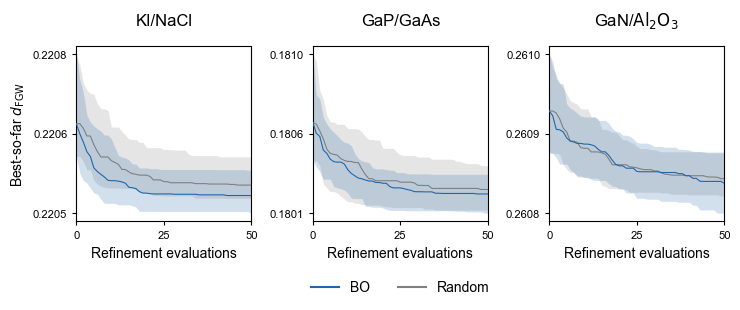

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(fig_width, fig_height), sharex=True)
plt.subplots_adjust(**fig_layout)

for ax, system, title, bo_paths, random_paths in zip(axes, systems, titles, bo_paths, random_paths):
    bo_df = pd.read_csv(bo_paths)
    random_df = pd.read_csv(random_paths)
    # Random convergence curves
    ax.fill_between(
        random_df["evaluation"],
        random_df["fgw_distance_q25"],
        random_df["fgw_distance_q75"],
        color=random_color,
        alpha=band_alpha,
        linewidth=0,
        zorder=1,
    )
    ax.plot(
        random_df["evaluation"],
        random_df["fgw_distance_median"],
        color=random_color,
        linewidth=0.8,
        zorder=3,
    )
    # BO convergence curves
    ax.fill_between(
        bo_df["evaluation"],
        bo_df["fgw_distance_q25"],
        bo_df["fgw_distance_q75"],
        color=bo_color,
        alpha=band_alpha,
        linewidth=0,
        zorder=2,
    )
    ax.plot(
        bo_df["evaluation"],
        bo_df["fgw_distance_median"],
        color=bo_color,
        linewidth=0.8,
        zorder=4,
    )
    # Set scale
    y_min = min(bo_df["fgw_distance_q25"].min(), random_df["fgw_distance_q25"].min())
    y_max = max(bo_df["fgw_distance_q75"].max(), random_df["fgw_distance_q75"].max())
    y_padding = 0.05 * (y_max - y_min)
    ax.set_ylim(y_min-y_padding, y_max+y_padding)
    ax.set_yticks(np.linspace(y_min, y_max, 3))
    ax.yaxis.set_major_formatter(FormatStrFormatter("%.4f"))
    evaluations = bo_df["evaluation"].iloc[-1]
    ax.set_xlim(0, evaluations)
    ax.set_xticks([0, evaluations/2, evaluations])
    ax.tick_params(direction="out", length=3, width=0.8)
    ax.set_box_aspect(1)
    ax.set_title(title, pad=15)
    ax.set_xlabel("Refinement evaluations")

axes[0].set_ylabel("Best-so-far $d_{\mathrm{FGW}}$")
legend_handles = [
    Line2D([0], [0], color=bo_color, label="BO"),
    Line2D([0], [0], color=random_color, label="Random"),
]

fig.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.08),
    ncol=2,
    frameon=False,
    handlelength=2,
    columnspacing=2,
)

plt.savefig("bo_random_convergence.pdf", dpi=300, bbox_inches="tight")
plt.show()
